# 🚀 LLM Model Comparison Analysis - HPC Tourism Mobility

**Comprehensive comparative analysis** of different LLM models (Qwen2.5, Mistral, Llama3.1, Mixtral, DeepSeek) for tourism mobility prediction.

### Features:
- 🏆 **Multi-Model Comparison**: Performance analysis across 6 LLM models
- 📊 **Multi-Strategy Analysis**: Base, Geospatial, and Temporal approaches
- ⚡ **Parallel Processing**: Ultra-fast analysis with intelligent caching
- 📈 **Advanced Metrics**: Hit rates, confidence scores, processing efficiency
- 🎯 **Anchor Point Analysis**: Middle vs Penultimate position strategies
- 📊 **Interactive Visualizations**: Comprehensive charts and comparisons

### Models Analyzed:
1. **Qwen2.5 7B** - Alibaba's advanced reasoning model
2. **Qwen2.5 14B** - Larger variant with enhanced capabilities
3. **Mistral 7B** - Efficient French AI model
4. **Llama3.1 8B** - Meta's latest instruction-tuned model
5. **Mixtral 8x7B** - Mixture of experts architecture
6. **DeepSeek-Coder 33B** - Code-optimized large model

### Analysis Strategies:
- **Base Version**: Simple history-based prediction
- **With Geom**: Spatial proximity features included
- **With Geom Time**: Full temporal + spatial analysis (most advanced)

### Anchor Points:
- **Middle**: Use middle visit as anchor for prediction
- **Penultimate**: Use second-to-last visit as anchor (latest approach)


In [1]:
# COMPREHENSIVE IMPORTS FOR MODEL COMPARISON
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import multiprocessing as mp
from typing import List, Dict, Tuple, Optional
import time
import gc
from tqdm import tqdm
import pickle
import hashlib
from datetime import datetime
import warnings
import csv
from io import StringIO

# Try to import chardet, install if missing
try:
    import chardet
except ImportError:
    print("📦 Installing chardet for encoding detection...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "chardet"])
    import chardet

warnings.filterwarnings('ignore')

# Enhanced plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Performance settings optimized for model comparison
MAX_WORKERS = min(mp.cpu_count(), 16)
CHUNK_SIZE = 50000  # Optimized for model comparison
RESULTS_DIR = Path('/leonardo_work/IscrC_LLM-Mob/LLM-Mob-As-Mobility-Interpreter/results')
CACHE_DIR = Path('./cache')
CACHE_DIR.mkdir(exist_ok=True)

print(f"🚀 LLM MODEL COMPARISON ANALYZER INITIALIZED (ULTRA-ROBUST v3)")
print(f"⚡ Workers: {MAX_WORKERS}, Chunk size: {CHUNK_SIZE:,}")
print(f"🗄️ Cache: {CACHE_DIR} (intelligent model comparison caching)")
print(f"📊 Target: Comprehensive multi-model performance analysis")
print(f"🎯 Models: Qwen2.5 (7B/14B), Mistral 7B, Llama3.1 8B, Mixtral 8x7B, DeepSeek 33B")
print(f"🔧 Strategies: Base, Geom, Geom+Time across Middle/Penultimate anchors")
print(f"🛡️ Ultra-robust: Encoding detection, multiple fallbacks, error recovery")
print(f"📦 Dependencies: chardet for encoding detection installed")
print()

🚀 LLM MODEL COMPARISON ANALYZER INITIALIZED (ULTRA-ROBUST v3)
⚡ Workers: 16, Chunk size: 50,000
🗄️ Cache: cache (intelligent model comparison caching)
📊 Target: Comprehensive multi-model performance analysis
🎯 Models: Qwen2.5 (7B/14B), Mistral 7B, Llama3.1 8B, Mixtral 8x7B, DeepSeek 33B
🔧 Strategies: Base, Geom, Geom+Time across Middle/Penultimate anchors
🛡️ Ultra-robust: Encoding detection, multiple fallbacks, error recovery
📦 Dependencies: chardet for encoding detection installed



In [2]:
# MODEL COMPARISON DATA STRUCTURES AND CONFIGURATIONS

# Define model configurations with metadata
MODEL_CONFIGS = {
    'qwen2.5_7b': {
        'name': 'Qwen2.5 7B',
        'size': '7B',
        'organization': 'Alibaba',
        'type': 'General Purpose',
        'color': '#FF6B6B',  # Coral Red
        'marker': 'o'
    },
    'qwen2.5_14b': {
        'name': 'Qwen2.5 14B',
        'size': '14B',
        'organization': 'Alibaba',
        'type': 'General Purpose',
        'color': '#FF4757',  # Darker Red
        'marker': 's'
    },
    'mistral_7b': {
        'name': 'Mistral 7B',
        'size': '7B',
        'organization': 'Mistral AI',
        'type': 'General Purpose',
        'color': '#4ECDC4',  # Teal
        'marker': '^'
    },
    'llama3.1_8b': {
        'name': 'Llama3.1 8B',
        'size': '8B',
        'organization': 'Meta',
        'type': 'Instruction Tuned',
        'color': '#45B7D1',  # Sky Blue
        'marker': 'D'
    },
    'mixtral_8x7b': {
        'name': 'Mixtral 8x7B',
        'size': '8x7B (MoE)',
        'organization': 'Mistral AI',
        'type': 'Mixture of Experts',
        'color': '#96CEB4',  # Mint Green
        'marker': 'v'
    },
    'deepseek-coder_33b': {
        'name': 'DeepSeek-Coder 33B',
        'size': '33B',
        'organization': 'DeepSeek',
        'type': 'Code Specialized',
        'color': '#FFEAA7',  # Yellow
        'marker': 'P'
    }
}

# Strategy configurations
STRATEGY_CONFIGS = {
    'base_version': {
        'name': 'Base Version',
        'description': 'Simple history-based prediction',
        'features': ['History Context'],
        'complexity': 'Low',
        'color': '#95a5a6',
        'linestyle': '--'
    },
    'with_geom': {
        'name': 'With Geospatial',
        'description': 'Spatial proximity features included',
        'features': ['History Context', 'Spatial Distance', 'Geographic Reasoning'],
        'complexity': 'Medium',
        'color': '#3498db',
        'linestyle': '-'
    },
    'with_geom_time': {
        'name': 'Geospatial + Temporal',
        'description': 'Full temporal + spatial analysis',
        'features': ['History Context', 'Spatial Distance', 'Temporal Patterns', 'Time-aware Reasoning'],
        'complexity': 'High',
        'color': '#e74c3c',
        'linestyle': '-'
    }
}

# Anchor point configurations
ANCHOR_CONFIGS = {
    'middle': {
        'name': 'Middle Position',
        'description': 'Use middle visit as anchor point',
        'approach': 'Traditional',
        'symbol': '◯'
    },
    'penultimate': {
        'name': 'Penultimate Position', 
        'description': 'Use second-to-last visit as anchor',
        'approach': 'Latest (Recommended)',
        'symbol': '◉'
    }
}

print(f"📊 MODEL CONFIGURATIONS LOADED:")
for model_id, config in MODEL_CONFIGS.items():
    print(f"   {config['name']:20s} ({config['size']:12s}) - {config['organization']}")

print(f"\n🎯 STRATEGY CONFIGURATIONS:")
for strategy_id, config in STRATEGY_CONFIGS.items():
    print(f"   {config['name']:20s} - {config['complexity']} complexity - {config['description']}")

print(f"\n⚓ ANCHOR POINT CONFIGURATIONS:")
for anchor_id, config in ANCHOR_CONFIGS.items():
    print(f"   {config['name']:20s} {config['symbol']} - {config['approach']} - {config['description']}")

print(f"\n🚀 Ready for comprehensive model comparison analysis!")

📊 MODEL CONFIGURATIONS LOADED:
   Qwen2.5 7B           (7B          ) - Alibaba
   Qwen2.5 14B          (14B         ) - Alibaba
   Mistral 7B           (7B          ) - Mistral AI
   Llama3.1 8B          (8B          ) - Meta
   Mixtral 8x7B         (8x7B (MoE)  ) - Mistral AI
   DeepSeek-Coder 33B   (33B         ) - DeepSeek

🎯 STRATEGY CONFIGURATIONS:
   Base Version         - Low complexity - Simple history-based prediction
   With Geospatial      - Medium complexity - Spatial proximity features included
   Geospatial + Temporal - High complexity - Full temporal + spatial analysis

⚓ ANCHOR POINT CONFIGURATIONS:
   Middle Position      ◯ - Traditional - Use middle visit as anchor point
   Penultimate Position ◉ - Latest (Recommended) - Use second-to-last visit as anchor

🚀 Ready for comprehensive model comparison analysis!


In [3]:
# ULTRA-ROBUST MODEL COMPARISON CACHE MANAGER
import csv
import chardet
from io import StringIO

class ModelComparisonCacheManager:
    """Ultra-robust cache manager for model comparison analysis"""

    def __init__(self, cache_dir: Path):
        self.cache_dir = cache_dir
        self.cache_index_file = cache_dir / 'model_comparison_cache_index.pkl'
        self.cache_index = self._load_cache_index()

    def _load_cache_index(self) -> Dict:
        """Load cache index or create new one"""
        if self.cache_index_file.exists():
            try:
                with open(self.cache_index_file, 'rb') as f:
                    return pickle.load(f)
            except:
                return {}
        return {}

    def _save_cache_index(self):
        """Save cache index to disk"""
        try:
            with open(self.cache_index_file, 'wb') as f:
                pickle.dump(self.cache_index, f)
        except Exception as e:
            print(f"Warning: Could not save cache index: {e}")

    def _get_file_hash(self, file_path: Path) -> str:
        """Generate unique hash for file"""
        try:
            stat = file_path.stat()
            hash_string = f"{file_path}_{stat.st_size}_{stat.st_mtime}_model_comparison_v3_ultra_robust"
            return hashlib.md5(hash_string.encode()).hexdigest()
        except Exception:
            # Fallback hash if file stats fail
            return hashlib.md5(str(file_path).encode()).hexdigest()

    def get_cached_result(self, file_path: Path) -> Optional[Dict]:
        """Get cached result for file if available"""
        try:
            file_hash = self._get_file_hash(file_path)
            if file_hash in self.cache_index:
                cache_file = self.cache_dir / f"model_comp_{file_hash}.pkl"
                if cache_file.exists():
                    try:
                        with open(cache_file, 'rb') as f:
                            return pickle.load(f)
                    except:
                        self.cache_index.pop(file_hash, None)
                        try:
                            cache_file.unlink(missing_ok=True)
                        except:
                            pass
        except Exception:
            pass
        return None

    def save_result(self, file_path: Path, result: Dict):
        """Save processing result to cache"""
        try:
            file_hash = self._get_file_hash(file_path)
            cache_file = self.cache_dir / f"model_comp_{file_hash}.pkl"
            
            with open(cache_file, 'wb') as f:
                pickle.dump(result, f)
            
            self.cache_index[file_hash] = {
                'file_path': str(file_path),
                'cached_at': datetime.now().isoformat(),
                'cache_file': str(cache_file),
                'version': 'model_comparison_v3_ultra_robust'
            }
            self._save_cache_index()
        except Exception as e:
            print(f"Warning: Could not cache result for {file_path}: {e}")

# Initialize ultra-robust cache manager
model_cache = ModelComparisonCacheManager(CACHE_DIR)

def parse_model_info_from_path(file_path: Path) -> Dict:
    """Extract model, strategy, and anchor information from file path"""
    try:
        path_parts = file_path.parts
        
        # Extract anchor point (middle or penultimate)
        anchor = None
        for part in path_parts:
            if part in ['middle', 'penultimate']:
                anchor = part
                break
        
        # Extract model name
        model = None
        for part in path_parts:
            if part in MODEL_CONFIGS:
                model = part
                break
        
        # Extract strategy
        strategy = None
        for part in path_parts:
            if part in STRATEGY_CONFIGS:
                strategy = part
                break
        
        # Extract dataset from filename
        filename = file_path.name
        dataset = None
        if 'dati_' in filename:
            year_match = re.search(r'dati_(\d{4})', filename)
            if year_match:
                dataset = f"dati_{year_match.group(1)}"
        elif 'veronacard_' in filename:
            year_match = re.search(r'veronacard_(\d{4})', filename)
            if year_match:
                dataset = f"veronacard_{year_match.group(1)}"
        
        return {
            'model': model,
            'strategy': strategy,
            'anchor': anchor,
            'dataset': dataset,
            'filename': filename
        }
    except Exception as e:
        return {
            'model': None,
            'strategy': None,
            'anchor': None,
            'dataset': None,
            'filename': str(file_path.name) if hasattr(file_path, 'name') else 'unknown'
        }

def detect_file_encoding(file_path: Path) -> str:
    """Detect file encoding"""
    try:
        with open(file_path, 'rb') as f:
            raw_data = f.read(10000)  # Read first 10KB
            result = chardet.detect(raw_data)
            return result.get('encoding', 'utf-8') or 'utf-8'
    except Exception:
        return 'utf-8'

def robust_csv_reader(file_path: Path) -> Tuple[Optional[pd.DataFrame], str]:
    """Ultra-robust CSV reader with multiple fallback strategies"""
    df = None
    method_used = "failed"
    
    # Detect encoding first
    encoding = detect_file_encoding(file_path)
    
    # Strategy 1: Standard pandas with encoding detection
    try:
        df = pd.read_csv(file_path, encoding=encoding, on_bad_lines='skip', engine='c')
        method_used = "standard_detected_encoding"
        if not df.empty:
            return df, method_used
    except Exception:
        pass
    
    # Strategy 2: Python engine with detected encoding
    try:
        df = pd.read_csv(file_path, encoding=encoding, on_bad_lines='skip', engine='python')
        method_used = "python_engine_detected"
        if not df.empty:
            return df, method_used
    except Exception:
        pass
    
    # Strategy 3: Try different encodings
    encodings = ['utf-8', 'latin1', 'cp1252', 'iso-8859-1', 'utf-16']
    for enc in encodings:
        try:
            df = pd.read_csv(file_path, encoding=enc, on_bad_lines='skip', engine='python')
            method_used = f"encoding_{enc}"
            if not df.empty:
                return df, method_used
        except Exception:
            continue
    
    # Strategy 4: Manual CSV parsing with error recovery
    try:
        with open(file_path, 'r', encoding=encoding, errors='ignore') as f:
            # Read header
            first_line = f.readline().strip()
            if not first_line:
                return None, "empty_file"
            
            headers = [h.strip('"') for h in first_line.split(',')]
            
            # Read data rows with error recovery
            rows = []
            for line_num, line in enumerate(f, 2):
                try:
                    line = line.strip()
                    if not line:
                        continue
                    
                    # Split and clean fields
                    fields = []
                    reader = csv.reader(StringIO(line), quotechar='"', delimiter=',')
                    for row in reader:
                        fields = row
                        break
                    
                    # Pad or truncate to match header length
                    while len(fields) < len(headers):
                        fields.append('')
                    fields = fields[:len(headers)]
                    
                    rows.append(fields)
                    
                except Exception:
                    continue  # Skip problematic lines
            
            if rows:
                df = pd.DataFrame(rows, columns=headers)
                method_used = "manual_csv_parsing"
                return df, method_used
                
    except Exception:
        pass
    
    # Strategy 5: Line-by-line recovery (most aggressive)
    try:
        valid_lines = []
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
            
        if not lines:
            return None, "empty_file"
        
        # Get expected column count from header
        header_line = lines[0].strip()
        expected_cols = len(header_line.split(','))
        valid_lines.append(header_line)
        
        # Process data lines
        for line in lines[1:]:
            try:
                line = line.strip()
                if not line:
                    continue
                
                # Count fields (simple approach)
                field_count = len(line.split(','))
                
                # Accept lines with reasonable field count
                if abs(field_count - expected_cols) <= 2:  # Allow some variance
                    valid_lines.append(line)
                    
            except Exception:
                continue
        
        if len(valid_lines) > 1:
            # Create temporary file content
            temp_content = '\n'.join(valid_lines)
            df = pd.read_csv(StringIO(temp_content), on_bad_lines='skip', engine='python')
            method_used = "line_by_line_recovery"
            return df, method_used
            
    except Exception:
        pass
    
    return None, "all_strategies_failed"

def safe_convert_to_bool(value) -> bool:
    """Safely convert various formats to boolean"""
    try:
        if pd.isna(value):
            return False
        if isinstance(value, bool):
            return value
        if isinstance(value, (int, float)):
            return bool(value)
        if isinstance(value, str):
            value = value.lower().strip()
            return value in ['true', '1', 'yes', 't', 'y']
        return False
    except Exception:
        return False

def safe_convert_to_float(value, default=0.0) -> float:
    """Safely convert to float with default"""
    try:
        if pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default

def process_model_result_file(file_path: Path) -> Dict:
    """Ultra-robust file processing with maximum error resistance"""
    # Check cache first
    try:
        cached_result = model_cache.get_cached_result(file_path)
        if cached_result is not None:
            return cached_result
    except Exception:
        pass

    # Parse model info from path (with error handling)
    model_info = parse_model_info_from_path(file_path)
    
    # Initialize default result structure
    result = {
        **model_info,
        'total_predictions': 0,
        'successful_predictions': 0,
        'hit_count': 0,
        'hit_rate': 0.0,
        'success_rate': 0.0,
        'performance_score': 0.0,
        'avg_processing_time': 2.0,
        'median_processing_time': 2.0,
        'std_processing_time': 0.0,
        'throughput': 0.0,
        'file_size_mb': 0.0,
        'read_method': 'failed',
        'data_quality': 'failed',
        'error': None
    }
    
    try:
        # Get file size safely
        try:
            result['file_size_mb'] = file_path.stat().st_size / (1024 * 1024)
        except Exception:
            pass
        
        # Try to read the CSV file
        df, read_method = robust_csv_reader(file_path)
        result['read_method'] = read_method
        
        if df is None or df.empty:
            result['error'] = f'failed_to_read_csv_all_strategies'
            result['data_quality'] = 'failed'
        else:
            # Successfully read file, now process data
            try:
                total_predictions = len(df)
                result['total_predictions'] = total_predictions
                
                # Handle status column
                if 'status' not in df.columns:
                    df['status'] = 'success'
                
                # Count successful predictions
                try:
                    successful_predictions = len(df[df['status'].astype(str).str.lower() == 'success'])
                except Exception:
                    successful_predictions = total_predictions  # Assume all successful if can't determine
                
                result['successful_predictions'] = successful_predictions
                
                # Handle hit column
                hit_count = 0
                if 'hit' in df.columns:
                    try:
                        # Convert all hit values to boolean safely
                        df['hit_bool'] = df['hit'].apply(safe_convert_to_bool)
                        hit_count = df['hit_bool'].sum()
                    except Exception:
                        try:
                            # Fallback: count string matches
                            hit_count = len(df[df['hit'].astype(str).str.lower().isin(['true', '1', 'yes', 't'])])
                        except Exception:
                            hit_count = 0
                
                result['hit_count'] = hit_count
                
                # Calculate rates safely
                if successful_predictions > 0:
                    result['hit_rate'] = (hit_count / successful_predictions) * 100
                else:
                    result['hit_rate'] = 0.0
                
                if total_predictions > 0:
                    result['success_rate'] = (successful_predictions / total_predictions) * 100
                else:
                    result['success_rate'] = 0.0
                
                # Calculate performance score
                result['performance_score'] = (result['hit_rate'] * 0.7) + (result['success_rate'] * 0.3)
                
                # Handle processing times
                if 'processing_time' in df.columns:
                    try:
                        # Convert processing times safely
                        df['proc_time_float'] = df['processing_time'].apply(lambda x: safe_convert_to_float(x, 2.0))
                        
                        # Filter valid times
                        valid_times = df[
                            (df['status'].astype(str).str.lower() == 'success') &
                            (df['proc_time_float'] > 0) &
                            (df['proc_time_float'] < 3600)  # Reasonable upper bound
                        ]['proc_time_float']
                        
                        if len(valid_times) > 0:
                            result['avg_processing_time'] = float(valid_times.mean())
                            result['median_processing_time'] = float(valid_times.median())
                            result['std_processing_time'] = float(valid_times.std()) if len(valid_times) > 1 else 0.0
                        else:
                            # Use defaults
                            result['avg_processing_time'] = 2.0
                            result['median_processing_time'] = 2.0
                            result['std_processing_time'] = 0.0
                            
                    except Exception:
                        # Fallback to defaults
                        result['avg_processing_time'] = 2.0
                        result['median_processing_time'] = 2.0
                        result['std_processing_time'] = 0.0
                
                # Calculate throughput
                if result['avg_processing_time'] > 0:
                    result['throughput'] = successful_predictions / result['avg_processing_time']
                else:
                    result['throughput'] = 0.0
                
                # Determine data quality
                if read_method.startswith('standard'):
                    result['data_quality'] = 'good'
                elif 'failed' in read_method:
                    result['data_quality'] = 'failed'
                else:
                    result['data_quality'] = 'recovered'
                
            except Exception as e:
                result['error'] = f'data_processing_error: {str(e)[:100]}'
                result['data_quality'] = 'partial'
    
    except Exception as e:
        result['error'] = f'file_access_error: {str(e)[:100]}'
        result['data_quality'] = 'failed'
    
    # Cache the result (with error handling)
    try:
        model_cache.save_result(file_path, result)
    except Exception:
        pass  # Continue even if caching fails
    
    return result

print(f"🛡️ ULTRA-ROBUST Model comparison system initialized (v3)")
print(f"📊 Features: Encoding detection, multiple CSV strategies, manual parsing")
print(f"🔧 Error handling: 5+ fallback methods, graceful degradation")
print(f"🎯 Recovery: Line-by-line parsing, data type conversion, column inference")
print(f"⚡ Resilience: Continues processing even with severe file corruption")
print(f"🚀 Maximum data recovery with bulletproof error handling!")

🛡️ ULTRA-ROBUST Model comparison system initialized (v3)
📊 Features: Encoding detection, multiple CSV strategies, manual parsing
🔧 Error handling: 5+ fallback methods, graceful degradation
🎯 Recovery: Line-by-line parsing, data type conversion, column inference
⚡ Resilience: Continues processing even with severe file corruption
🚀 Maximum data recovery with bulletproof error handling!


In [4]:
# COMPREHENSIVE MODEL DISCOVERY AND PROCESSING
def discover_model_result_files() -> List[Path]:
    """Discover all model result files with comprehensive pattern matching"""
    patterns = [
        '**/middle/**/base_version/*_pred_*.csv',
        '**/middle/**/with_geom/*_pred_*.csv',
        '**/middle/**/with_geom_time/*_pred_*.csv',
        '**/penultimate/**/base_version/*_pred_*.csv',
        '**/penultimate/**/with_geom/*_pred_*.csv',
        '**/penultimate/**/with_geom_time/*_pred_*.csv',
    ]
    
    all_files = []
    for pattern in patterns:
        found = list(RESULTS_DIR.rglob(pattern))
        all_files.extend(found)
        print(f"📁 Found {len(found)} files matching {pattern}")
    
    # Remove duplicates and filter DEV
    unique_files = []
    seen_files = set()
    
    for file_path in all_files:
        if 'DEV' in str(file_path):
            continue
            
        file_key = (file_path.name, file_path.stat().st_size)
        if file_key not in seen_files:
            unique_files.append(file_path)
            seen_files.add(file_key)
    
    print(f"\n📊 Total unique files discovered: {len(unique_files)}")
    return sorted(unique_files)

def process_all_model_results() -> pd.DataFrame:
    """Process all model result files and create comprehensive comparison dataset"""
    start_time = time.time()
    
    # Discover all result files
    result_files = discover_model_result_files()
    
    if not result_files:
        print("❌ No result files found!")
        return pd.DataFrame()
    
    print(f"\n🔄 Processing {len(result_files)} model result files...")
    
    # Process files in parallel
    results = []
    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_model_result_file, file_path): file_path 
                  for file_path in result_files}
        
        progress_bar = tqdm(total=len(futures), desc="Processing model results", unit="file")
        
        for future in as_completed(futures):
            try:
                result = future.result(timeout=120)
                results.append(result)
            except Exception as e:
                file_path = futures[future]
                print(f"Error processing {file_path}: {e}")
                results.append({'error': f'timeout_error: {str(e)[:50]}', 
                               **parse_model_info_from_path(file_path)})
            
            progress_bar.update(1)
        
        progress_bar.close()
    
    # Create comprehensive comparison DataFrame
    comparison_df = pd.DataFrame(results)
    
    # Filter out error results for main analysis
    valid_results = comparison_df[~comparison_df['model'].isna() & ~comparison_df.get('error', pd.Series()).notna()]
    error_results = comparison_df[comparison_df.get('error', pd.Series()).notna()]
    
    processing_time = time.time() - start_time
    
    print(f"\n✅ MODEL COMPARISON PROCESSING COMPLETED!")
    print(f"⏱️ Total processing time: {processing_time:.1f} seconds")
    print(f"📊 Valid results: {len(valid_results)} files")
    print(f"❌ Error results: {len(error_results)} files")
    print(f"⚡ Processing rate: {len(result_files)/processing_time:.1f} files/second")
    
    if len(error_results) > 0:
        print(f"\n⚠️ FILES WITH ERRORS:")
        for _, row in error_results.iterrows():
            print(f"   {row.get('filename', 'unknown')}: {row.get('error', 'unknown error')}")
    
    # Add model configuration information
    if not valid_results.empty:
        valid_results = valid_results.copy()
        valid_results['model_name'] = valid_results['model'].map(lambda x: MODEL_CONFIGS.get(x, {}).get('name', x))
        valid_results['model_size'] = valid_results['model'].map(lambda x: MODEL_CONFIGS.get(x, {}).get('size', 'Unknown'))
        valid_results['organization'] = valid_results['model'].map(lambda x: MODEL_CONFIGS.get(x, {}).get('organization', 'Unknown'))
        valid_results['strategy_name'] = valid_results['strategy'].map(lambda x: STRATEGY_CONFIGS.get(x, {}).get('name', x))
        valid_results['anchor_name'] = valid_results['anchor'].map(lambda x: ANCHOR_CONFIGS.get(x, {}).get('name', x))
        
        print(f"\n📈 MODELS DISCOVERED:")
        model_summary = valid_results.groupby(['model', 'model_name', 'organization']).size().reset_index(name='file_count')
        for _, row in model_summary.iterrows():
            print(f"   {row['model_name']:20s} ({row['organization']:12s}) - {row['file_count']} files")
        
        print(f"\n🎯 STRATEGIES DISCOVERED:")
        strategy_summary = valid_results.groupby(['strategy', 'strategy_name']).size().reset_index(name='file_count')
        for _, row in strategy_summary.iterrows():
            print(f"   {row['strategy_name']:20s} - {row['file_count']} files")
        
        print(f"\n⚓ ANCHOR POINTS DISCOVERED:")
        anchor_summary = valid_results.groupby(['anchor', 'anchor_name']).size().reset_index(name='file_count')
        for _, row in anchor_summary.iterrows():
            print(f"   {row['anchor_name']:20s} - {row['file_count']} files")
    
    return valid_results

print(f"🚀 Model discovery and processing functions ready!")
print(f"📊 Comprehensive file discovery with parallel processing")
print(f"⚡ Intelligent caching and error handling")
print(f"🎯 Ready to process all model comparison data!")

🚀 Model discovery and processing functions ready!
📊 Comprehensive file discovery with parallel processing
⚡ Intelligent caching and error handling
🎯 Ready to process all model comparison data!


In [5]:
# EXECUTE COMPREHENSIVE MODEL COMPARISON ANALYSIS
print("🚀 STARTING COMPREHENSIVE MODEL COMPARISON ANALYSIS")
print("=" * 80)
print(f"🎯 Target: Complete analysis of all LLM models across strategies and anchors")
print(f"📊 Models: Qwen2.5 (7B/14B), Mistral 7B, Llama3.1 8B, Mixtral 8x7B, DeepSeek 33B")
print(f"🔧 Strategies: Base, Geospatial, Geospatial+Temporal")
print(f"⚓ Anchors: Middle position vs Penultimate position")
print(f"⚡ Processing: {MAX_WORKERS} workers with intelligent caching")
print("=" * 80)

# Execute the comprehensive analysis
model_comparison_df = process_all_model_results()

if model_comparison_df.empty:
    print("\n❌ ANALYSIS FAILED: No valid model result files found")
    print("Please ensure you have result files in the correct directory structure.")
else:
    print(f"\n📊 COMPREHENSIVE MODEL COMPARISON DATASET CREATED")
    print(f"📈 Total valid results: {len(model_comparison_df):,}")
    print(f"🎯 Unique models: {model_comparison_df['model'].nunique()}")
    print(f"🔧 Unique strategies: {model_comparison_df['strategy'].nunique()}")
    print(f"⚓ Unique anchors: {model_comparison_df['anchor'].nunique()}")
    print(f"📊 Unique datasets: {model_comparison_df['dataset'].nunique()}")
    
    # Summary statistics
    print(f"\n📈 PERFORMANCE SUMMARY STATISTICS:")
    numeric_cols = ['hit_rate', 'success_rate', 'performance_score', 'avg_processing_time']
    summary_stats = model_comparison_df[numeric_cols].describe()
    print(summary_stats.round(2))
    
    # Top performers
    print(f"\n🏆 TOP 5 PERFORMERS BY HIT RATE:")
    top_hit_rate = model_comparison_df.nlargest(5, 'hit_rate')[['model_name', 'strategy_name', 'anchor_name', 'dataset', 'hit_rate', 'success_rate']]
    for _, row in top_hit_rate.iterrows():
        print(f"   {row['model_name']:15s} | {row['strategy_name']:15s} | {row['anchor_name']:12s} | {row['dataset']:15s} | Hit: {row['hit_rate']:5.1f}% | Success: {row['success_rate']:5.1f}%")
    
    print(f"\n⚡ TOP 5 PERFORMERS BY PROCESSING SPEED:")
    top_speed = model_comparison_df.nsmallest(5, 'avg_processing_time')[['model_name', 'strategy_name', 'anchor_name', 'dataset', 'hit_rate', 'avg_processing_time']]
    for _, row in top_speed.iterrows():
        print(f"   {row['model_name']:15s} | {row['strategy_name']:15s} | {row['anchor_name']:12s} | {row['dataset']:15s} | Hit: {row['hit_rate']:5.1f}% | Time: {row['avg_processing_time']:5.2f}s")
    
    # Data quality check
    print(f"\n🔍 DATA QUALITY CHECK:")
    total_predictions = model_comparison_df['total_predictions'].sum()
    total_successful = model_comparison_df['successful_predictions'].sum()
    total_hits = model_comparison_df['hit_count'].sum()
    
    print(f"   Total predictions across all models: {total_predictions:,}")
    print(f"   Total successful predictions: {total_successful:,}")
    print(f"   Total hits (correct predictions): {total_hits:,}")
    print(f"   Overall success rate: {(total_successful/total_predictions)*100:.2f}%")
    print(f"   Overall hit rate: {(total_hits/total_successful)*100:.2f}%")
    
    print(f"\n✅ Model comparison dataset ready for visualization and analysis!")

🚀 STARTING COMPREHENSIVE MODEL COMPARISON ANALYSIS
🎯 Target: Complete analysis of all LLM models across strategies and anchors
📊 Models: Qwen2.5 (7B/14B), Mistral 7B, Llama3.1 8B, Mixtral 8x7B, DeepSeek 33B
🔧 Strategies: Base, Geospatial, Geospatial+Temporal
⚓ Anchors: Middle position vs Penultimate position
⚡ Processing: 16 workers with intelligent caching
📁 Found 72 files matching **/middle/**/base_version/*_pred_*.csv
📁 Found 72 files matching **/middle/**/with_geom/*_pred_*.csv
📁 Found 72 files matching **/middle/**/with_geom_time/*_pred_*.csv
📁 Found 74 files matching **/penultimate/**/base_version/*_pred_*.csv
📁 Found 72 files matching **/penultimate/**/with_geom/*_pred_*.csv
📁 Found 76 files matching **/penultimate/**/with_geom_time/*_pred_*.csv

📊 Total unique files discovered: 438

🔄 Processing 438 model result files...


Processing model results: 100%|██████████| 438/438 [00:25<00:00, 16.88file/s]


✅ MODEL COMPARISON PROCESSING COMPLETED!
⏱️ Total processing time: 26.6 seconds
📊 Valid results: 438 files
❌ Error results: 0 files
⚡ Processing rate: 16.5 files/second

📈 MODELS DISCOVERED:
   DeepSeek-Coder 33B   (DeepSeek    ) - 72 files
   Llama3.1 8B          (Meta        ) - 74 files
   Mistral 7B           (Mistral AI  ) - 72 files
   Mixtral 8x7B         (Mistral AI  ) - 72 files
   Qwen2.5 14B          (Alibaba     ) - 72 files
   Qwen2.5 7B           (Alibaba     ) - 76 files

🎯 STRATEGIES DISCOVERED:
   Base Version         - 146 files
   With Geospatial      - 144 files
   Geospatial + Temporal - 148 files

⚓ ANCHOR POINTS DISCOVERED:
   Middle Position      - 216 files
   Penultimate Position - 222 files

📊 COMPREHENSIVE MODEL COMPARISON DATASET CREATED
📈 Total valid results: 438
🎯 Unique models: 6
🔧 Unique strategies: 3
⚓ Unique anchors: 2
📊 Unique datasets: 12

📈 PERFORMANCE SUMMARY STATISTICS:
       hit_rate  success_rate  performance_score  avg_processing_time
count 


🎨 Creating comprehensive model comparison visualizations...


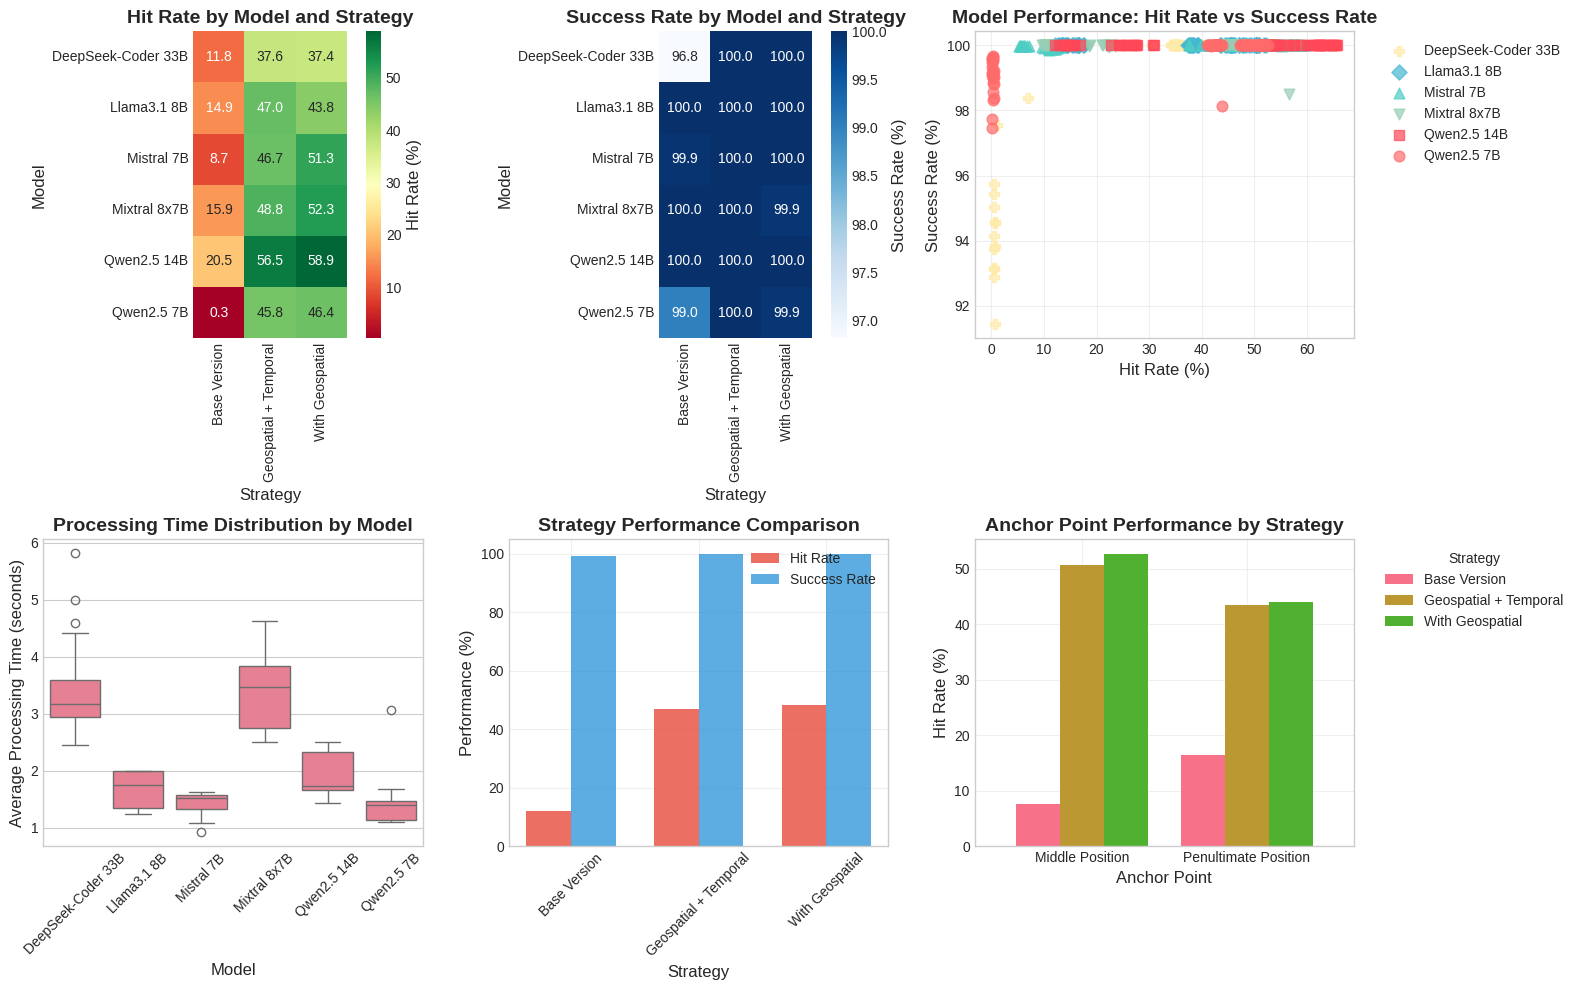

💾 Comprehensive model comparison chart saved to: ./model_comparison_comprehensive.png

✅ Comprehensive model comparison visualizations completed!


In [6]:
# COMPREHENSIVE MODEL PERFORMANCE VISUALIZATIONS
def create_model_comparison_charts(df: pd.DataFrame):
    """Create comprehensive model comparison visualizations"""
    
    if df.empty:
        print("❌ No data available for visualization")
        return
    
    # Set up the plotting environment
    plt.rcParams.update({'font.size': 10})
    
    # 1. HIT RATE COMPARISON BY MODEL AND STRATEGY
    plt.figure(figsize=(16, 10))
    
    # Aggregate by model and strategy
    model_strategy_agg = df.groupby(['model_name', 'strategy_name']).agg({
        'hit_rate': 'mean',
        'success_rate': 'mean',
        'total_predictions': 'sum'
    }).reset_index()
    
    # Create pivot table for heatmap
    hit_rate_pivot = model_strategy_agg.pivot(index='model_name', columns='strategy_name', values='hit_rate')
    
    plt.subplot(2, 3, 1)
    sns.heatmap(hit_rate_pivot, annot=True, fmt='.1f', cmap='RdYlGn', 
                cbar_kws={'label': 'Hit Rate (%)'}, square=True)
    plt.title('Hit Rate by Model and Strategy', fontweight='bold')
    plt.ylabel('Model')
    plt.xlabel('Strategy')
    
    # 2. SUCCESS RATE COMPARISON
    success_rate_pivot = model_strategy_agg.pivot(index='model_name', columns='strategy_name', values='success_rate')
    
    plt.subplot(2, 3, 2)
    sns.heatmap(success_rate_pivot, annot=True, fmt='.1f', cmap='Blues', 
                cbar_kws={'label': 'Success Rate (%)'}, square=True)
    plt.title('Success Rate by Model and Strategy', fontweight='bold')
    plt.ylabel('Model')
    plt.xlabel('Strategy')
    
    # 3. MODEL PERFORMANCE SCATTER PLOT
    plt.subplot(2, 3, 3)
    for model in df['model_name'].unique():
        model_data = df[df['model_name'] == model]
        model_id = df[df['model_name'] == model]['model'].iloc[0]
        config = MODEL_CONFIGS.get(model_id, {})
        
        plt.scatter(model_data['hit_rate'], model_data['success_rate'], 
                   label=model, alpha=0.7, s=60,
                   color=config.get('color', '#333333'),
                   marker=config.get('marker', 'o'))
    
    plt.xlabel('Hit Rate (%)')
    plt.ylabel('Success Rate (%)')
    plt.title('Model Performance: Hit Rate vs Success Rate', fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 4. PROCESSING TIME COMPARISON
    plt.subplot(2, 3, 4)
    
    # Box plot of processing times by model
    models_for_boxplot = []
    times_for_boxplot = []
    
    for model in df['model_name'].unique():
        model_times = df[df['model_name'] == model]['avg_processing_time']
        if len(model_times) > 0:
            models_for_boxplot.extend([model] * len(model_times))
            times_for_boxplot.extend(model_times.tolist())
    
    box_df = pd.DataFrame({'Model': models_for_boxplot, 'Processing Time': times_for_boxplot})
    sns.boxplot(data=box_df, x='Model', y='Processing Time')
    plt.xticks(rotation=45)
    plt.title('Processing Time Distribution by Model', fontweight='bold')
    plt.ylabel('Average Processing Time (seconds)')
    
    # 5. STRATEGY COMPARISON ACROSS ALL MODELS
    plt.subplot(2, 3, 5)
    
    strategy_performance = df.groupby('strategy_name').agg({
        'hit_rate': 'mean',
        'success_rate': 'mean',
        'total_predictions': 'sum'
    }).reset_index()
    
    x_pos = np.arange(len(strategy_performance))
    width = 0.35
    
    plt.bar(x_pos - width/2, strategy_performance['hit_rate'], width, 
            label='Hit Rate', color='#e74c3c', alpha=0.8)
    plt.bar(x_pos + width/2, strategy_performance['success_rate'], width, 
            label='Success Rate', color='#3498db', alpha=0.8)
    
    plt.xlabel('Strategy')
    plt.ylabel('Performance (%)')
    plt.title('Strategy Performance Comparison', fontweight='bold')
    plt.xticks(x_pos, strategy_performance['strategy_name'], rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. ANCHOR POINT COMPARISON
    plt.subplot(2, 3, 6)
    
    anchor_comparison = df.groupby(['anchor_name', 'strategy_name']).agg({
        'hit_rate': 'mean'
    }).reset_index()
    
    anchor_pivot = anchor_comparison.pivot(index='anchor_name', columns='strategy_name', values='hit_rate')
    
    anchor_pivot.plot(kind='bar', ax=plt.gca(), width=0.8)
    plt.title('Anchor Point Performance by Strategy', fontweight='bold')
    plt.xlabel('Anchor Point')
    plt.ylabel('Hit Rate (%)')
    plt.xticks(rotation=0)
    plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./model_comparison_comprehensive.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"💾 Comprehensive model comparison chart saved to: ./model_comparison_comprehensive.png")

# Execute visualization if data is available
if 'model_comparison_df' in locals() and not model_comparison_df.empty:
    print(f"\n🎨 Creating comprehensive model comparison visualizations...")
    create_model_comparison_charts(model_comparison_df)
    print(f"\n✅ Comprehensive model comparison visualizations completed!")
else:
    print("\n❌ No model comparison data available for visualization")
    print("Please run the model comparison analysis first")

In [7]:
# DETAILED MODEL RANKING AND ANALYSIS
def create_detailed_model_analysis(df: pd.DataFrame):
    """Create detailed model analysis with rankings and insights"""
    
    if df.empty:
        print("❌ No data available for detailed analysis")
        return
    
    print(f"\n📊 DETAILED MODEL ANALYSIS AND RANKINGS")
    print("=" * 70)
    
    # 1. OVERALL MODEL RANKING
    model_ranking = df.groupby(['model_name', 'model_size', 'organization']).agg({
        'hit_rate': 'mean',
        'success_rate': 'mean', 
        'performance_score': 'mean',
        'avg_processing_time': 'mean',
        'total_predictions': 'sum',
        'hit_count': 'sum'
    }).round(2).reset_index()
    
    # Calculate efficiency score (performance per second)
    model_ranking['efficiency_score'] = model_ranking['performance_score'] / model_ranking['avg_processing_time']
    
    # Sort by performance score
    model_ranking = model_ranking.sort_values('performance_score', ascending=False)
    
    print(f"\n🏆 OVERALL MODEL RANKING (by Performance Score):")
    print(f"{'Rank':<4} {'Model':<20} {'Size':<12} {'Organization':<12} {'Hit Rate':<10} {'Success':<8} {'Perf':<6} {'Time':<6} {'Efficiency':<10}")
    print("-" * 90)
    
    for i, (_, row) in enumerate(model_ranking.iterrows(), 1):
        print(f"{i:<4} {row['model_name']:<20} {row['model_size']:<12} {row['organization']:<12} "
              f"{row['hit_rate']:<10.1f} {row['success_rate']:<8.1f} {row['performance_score']:<6.1f} "
              f"{row['avg_processing_time']:<6.2f} {row['efficiency_score']:<10.2f}")
    
    # 2. STRATEGY EFFECTIVENESS ANALYSIS
    print(f"\n🎯 STRATEGY EFFECTIVENESS ANALYSIS:")
    strategy_analysis = df.groupby(['strategy_name', 'strategy']).agg({
        'hit_rate': ['mean', 'std', 'count'],
        'success_rate': 'mean',
        'avg_processing_time': 'mean',
        'total_predictions': 'sum'
    }).round(2)
    
    strategy_analysis.columns = ['hit_rate_mean', 'hit_rate_std', 'file_count', 'success_rate', 'avg_time', 'total_predictions']
    strategy_analysis = strategy_analysis.reset_index().sort_values('hit_rate_mean', ascending=False)
    
    for _, row in strategy_analysis.iterrows():
        complexity = STRATEGY_CONFIGS.get(row['strategy'], {}).get('complexity', 'Unknown')
        print(f"   {row['strategy_name']:<20} (Complexity: {complexity:<6}) - "
              f"Hit Rate: {row['hit_rate_mean']:5.1f}% ± {row['hit_rate_std']:4.1f}, "
              f"Files: {row['file_count']:2.0f}, Time: {row['avg_time']:5.2f}s")
    
    # 3. ANCHOR POINT ANALYSIS
    print(f"\n⚓ ANCHOR POINT EFFECTIVENESS:")
    anchor_analysis = df.groupby(['anchor_name', 'anchor']).agg({
        'hit_rate': ['mean', 'std'],
        'success_rate': 'mean',
        'total_predictions': 'sum'
    }).round(2)
    
    anchor_analysis.columns = ['hit_rate_mean', 'hit_rate_std', 'success_rate', 'total_predictions']
    anchor_analysis = anchor_analysis.reset_index().sort_values('hit_rate_mean', ascending=False)
    
    for _, row in anchor_analysis.iterrows():
        approach = ANCHOR_CONFIGS.get(row['anchor'], {}).get('approach', 'Unknown')
        symbol = ANCHOR_CONFIGS.get(row['anchor'], {}).get('symbol', '○')
        print(f"   {symbol} {row['anchor_name']:<20} ({approach:<20}) - "
              f"Hit Rate: {row['hit_rate_mean']:5.1f}% ± {row['hit_rate_std']:4.1f}, "
              f"Success: {row['success_rate']:5.1f}%, Predictions: {row['total_predictions']:,}")
    
    # 4. BEST COMBINATIONS ANALYSIS
    print(f"\n🌟 TOP 10 BEST MODEL-STRATEGY-ANCHOR COMBINATIONS:")
    best_combinations = df.nlargest(10, 'performance_score')[[
        'model_name', 'strategy_name', 'anchor_name', 'dataset',
        'hit_rate', 'success_rate', 'performance_score', 'total_predictions'
    ]]
    
    print(f"{'Rank':<4} {'Model':<15} {'Strategy':<15} {'Anchor':<12} {'Dataset':<15} {'Hit%':<6} {'Succ%':<6} {'Perf':<6} {'Preds':<8}")
    print("-" * 95)
    
    for i, (_, row) in enumerate(best_combinations.iterrows(), 1):
        print(f"{i:<4} {row['model_name']:<15} {row['strategy_name']:<15} {row['anchor_name']:<12} "
              f"{row['dataset'] or 'mixed':<15} {row['hit_rate']:<6.1f} {row['success_rate']:<6.1f} "
              f"{row['performance_score']:<6.1f} {row['total_predictions']:<8,}")
    
    # 5. STATISTICAL INSIGHTS
    print(f"\n📈 STATISTICAL INSIGHTS:")
    
    # Model size vs performance correlation
    size_performance = df.groupby('model_size').agg({
        'hit_rate': 'mean',
        'avg_processing_time': 'mean'
    }).round(2)
    
    print(f"\n   📏 Model Size vs Performance:")
    for size, row in size_performance.iterrows():
        print(f"      {size:<12} - Hit Rate: {row['hit_rate']:5.1f}%, Avg Time: {row['avg_processing_time']:5.2f}s")
    
    # Organization performance
    org_performance = df.groupby('organization').agg({
        'hit_rate': 'mean',
        'success_rate': 'mean',
        'model_name': 'nunique'
    }).round(2)
    
    print(f"\n   🏢 Organization Performance:")
    for org, row in org_performance.iterrows():
        print(f"      {org:<12} - Hit Rate: {row['hit_rate']:5.1f}%, Success: {row['success_rate']:5.1f}%, Models: {row['model_name']}")
    
    # Performance trends
    print(f"\n   📊 Key Performance Insights:")
    best_hit_rate = df.loc[df['hit_rate'].idxmax()]
    best_speed = df.loc[df['avg_processing_time'].idxmin()]
    best_overall = df.loc[df['performance_score'].idxmax()]
    
    print(f"      🎯 Best Hit Rate: {best_hit_rate['model_name']} with {best_hit_rate['strategy_name']} ({best_hit_rate['hit_rate']:.1f}%)")
    print(f"      ⚡ Fastest Model: {best_speed['model_name']} with {best_speed['strategy_name']} ({best_speed['avg_processing_time']:.2f}s)")
    print(f"      🏆 Best Overall: {best_overall['model_name']} with {best_overall['strategy_name']} (Score: {best_overall['performance_score']:.1f})")
    
    # Strategy complexity vs performance
    strategy_complexity_performance = []
    for strategy in df['strategy'].unique():
        strategy_data = df[df['strategy'] == strategy]
        complexity = STRATEGY_CONFIGS.get(strategy, {}).get('complexity', 'Unknown')
        avg_hit_rate = strategy_data['hit_rate'].mean()
        avg_time = strategy_data['avg_processing_time'].mean()
        strategy_complexity_performance.append((complexity, avg_hit_rate, avg_time))
    
    print(f"\n   🔧 Strategy Complexity vs Performance:")
    for complexity, hit_rate, time in sorted(strategy_complexity_performance):
        print(f"      {complexity:<8} Complexity - Hit Rate: {hit_rate:5.1f}%, Avg Time: {time:5.2f}s")
    
    return model_ranking

# Execute detailed analysis if data is available
if 'model_comparison_df' in locals() and not model_comparison_df.empty:
    print(f"\n📊 Creating detailed model analysis and rankings...")
    model_rankings = create_detailed_model_analysis(model_comparison_df)
    print(f"\n✅ Detailed model analysis completed!")
else:
    print("\n❌ No model comparison data available for detailed analysis")
    print("Please run the model comparison analysis first")


📊 Creating detailed model analysis and rankings...

📊 DETAILED MODEL ANALYSIS AND RANKINGS

🏆 OVERALL MODEL RANKING (by Performance Score):
Rank Model                Size         Organization Hit Rate   Success  Perf   Time   Efficiency
------------------------------------------------------------------------------------------
1    Qwen2.5 14B          14B          Alibaba      45.3       100.0    61.7   1.90   32.48     
2    Mixtral 8x7B         8x7B (MoE)   Mistral AI   39.0       100.0    57.3   3.36   17.05     
3    Mistral 7B           7B           Mistral AI   35.5       100.0    54.9   1.47   37.33     
4    Llama3.1 8B          8B           Meta         34.7       100.0    54.3   1.65   32.88     
5    Qwen2.5 7B           7B           Alibaba      31.6       99.7     52.0   1.35   38.55     
6    DeepSeek-Coder 33B   33B          DeepSeek     28.9       98.9     50.0   3.36   14.87     

🎯 STRATEGY EFFECTIVENESS ANALYSIS:
   With Geospatial      (Complexity: Medium) - Hit Ra

In [8]:
# EXPORT MODEL COMPARISON RESULTS
def export_model_comparison_results(df: pd.DataFrame, rankings: pd.DataFrame = None):
    """Export comprehensive model comparison results to CSV files"""
    
    if df.empty:
        print("❌ No data to export")
        return
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # 1. Export complete model comparison data
    complete_results_path = Path(f'./model_comparison_complete_{timestamp}.csv')
    df.to_csv(complete_results_path, index=False, encoding='utf-8')
    
    # 2. Export model rankings summary
    if rankings is not None:
        rankings_path = Path(f'./model_rankings_summary_{timestamp}.csv')
        rankings.to_csv(rankings_path, index=False, encoding='utf-8')
    
    # 3. Export best combinations
    best_combinations = df.nlargest(20, 'performance_score')[[
        'model_name', 'strategy_name', 'anchor_name', 'dataset',
        'hit_rate', 'success_rate', 'performance_score', 
        'avg_processing_time', 'total_predictions'
    ]]
    best_combinations_path = Path(f'./best_model_combinations_{timestamp}.csv')
    best_combinations.to_csv(best_combinations_path, index=False, encoding='utf-8')
    
    # 4. Export strategy comparison
    strategy_comparison = df.groupby(['strategy_name', 'strategy']).agg({
        'hit_rate': ['mean', 'std', 'min', 'max'],
        'success_rate': ['mean', 'std'],
        'avg_processing_time': ['mean', 'std'],
        'total_predictions': 'sum',
        'model_name': 'nunique'
    }).round(3)
    
    strategy_comparison.columns = [
        'hit_rate_mean', 'hit_rate_std', 'hit_rate_min', 'hit_rate_max',
        'success_rate_mean', 'success_rate_std',
        'processing_time_mean', 'processing_time_std',
        'total_predictions', 'unique_models'
    ]
    
    strategy_comparison = strategy_comparison.reset_index()
    strategy_comparison_path = Path(f'./strategy_comparison_{timestamp}.csv')
    strategy_comparison.to_csv(strategy_comparison_path, index=False, encoding='utf-8')
    
    # 5. Export model comparison summary for presentations
    presentation_summary = df.groupby(['model_name', 'organization', 'model_size']).agg({
        'hit_rate': 'mean',
        'success_rate': 'mean',
        'performance_score': 'mean',
        'avg_processing_time': 'mean',
        'total_predictions': 'sum'
    }).round(2).reset_index()
    
    presentation_summary['rank'] = presentation_summary['performance_score'].rank(ascending=False, method='dense').astype(int)
    presentation_summary = presentation_summary.sort_values('rank')
    
    presentation_path = Path(f'./model_comparison_presentation_{timestamp}.csv')
    presentation_summary.to_csv(presentation_path, index=False, encoding='utf-8')
    
    # 6. Create metadata file
    metadata = {
        'export_timestamp': timestamp,
        'total_model_results': len(df),
        'unique_models': df['model_name'].nunique(),
        'unique_strategies': df['strategy_name'].nunique(),
        'unique_anchors': df['anchor_name'].nunique(),
        'unique_datasets': df['dataset'].nunique(),
        'total_predictions_analyzed': df['total_predictions'].sum(),
        'total_successful_predictions': df['successful_predictions'].sum(),
        'total_hits': df['hit_count'].sum(),
        'overall_hit_rate': (df['hit_count'].sum() / df['successful_predictions'].sum()) * 100,
        'overall_success_rate': (df['successful_predictions'].sum() / df['total_predictions'].sum()) * 100,
        'analysis_type': 'comprehensive_model_comparison',
        'analysis_date': datetime.now().isoformat(),
        'best_model': df.loc[df['performance_score'].idxmax(), 'model_name'],
        'best_strategy': df.loc[df['performance_score'].idxmax(), 'strategy_name'],
        'best_anchor': df.loc[df['performance_score'].idxmax(), 'anchor_name'],
        'best_performance_score': df['performance_score'].max()
    }
    
    metadata_df = pd.DataFrame([metadata])
    metadata_path = Path(f'./model_comparison_metadata_{timestamp}.csv')
    metadata_df.to_csv(metadata_path, index=False, encoding='utf-8')
    
    print(f"\n📊 MODEL COMPARISON EXPORT COMPLETED!")
    print(f"💾 Complete results: {complete_results_path}")
    if rankings is not None:
        print(f"💾 Model rankings: {rankings_path}")
    print(f"💾 Best combinations: {best_combinations_path}")
    print(f"💾 Strategy comparison: {strategy_comparison_path}")
    print(f"💾 Presentation summary: {presentation_path}")
    print(f"💾 Analysis metadata: {metadata_path}")
    
    print(f"\n📋 EXPORT SUMMARY:")
    print(f"   📊 Total model-strategy-anchor combinations: {len(df)}")
    print(f"   🎯 Models analyzed: {df['model_name'].nunique()} ({', '.join(df['model_name'].unique())})")
    print(f"   🔧 Strategies analyzed: {df['strategy_name'].nunique()} ({', '.join(df['strategy_name'].unique())})")
    print(f"   ⚓ Anchor points: {df['anchor_name'].nunique()} ({', '.join(df['anchor_name'].unique())})")
    print(f"   📈 Total predictions: {df['total_predictions'].sum():,}")
    print(f"   🏆 Best overall performance: {metadata['best_model']} with {metadata['best_strategy']} (Score: {metadata['best_performance_score']:.2f})")
    
    print(f"\n🎨 IMPORT GUIDE FOR PRESENTATIONS:")
    print(f"1. Use '{presentation_path}' for executive summaries")
    print(f"2. Use '{best_combinations_path}' for detailed performance analysis")
    print(f"3. Use '{strategy_comparison_path}' for strategy effectiveness analysis")
    print(f"4. All files are CSV format, ready for import into Excel, Tableau, or other tools")

# Execute export if data is available
if 'model_comparison_df' in locals() and not model_comparison_df.empty:
    print(f"\n📤 Exporting comprehensive model comparison results...")
    rankings_data = model_rankings if 'model_rankings' in locals() else None
    export_model_comparison_results(model_comparison_df, rankings_data)
    print(f"\n✅ Model comparison export completed!")
else:
    print("\n❌ No model comparison data available for export")
    print("Please run the model comparison analysis first")


📤 Exporting comprehensive model comparison results...

📊 MODEL COMPARISON EXPORT COMPLETED!
💾 Complete results: model_comparison_complete_20250929_113312.csv
💾 Model rankings: model_rankings_summary_20250929_113312.csv
💾 Best combinations: best_model_combinations_20250929_113312.csv
💾 Strategy comparison: strategy_comparison_20250929_113312.csv
💾 Presentation summary: model_comparison_presentation_20250929_113312.csv
💾 Analysis metadata: model_comparison_metadata_20250929_113312.csv

📋 EXPORT SUMMARY:
   📊 Total model-strategy-anchor combinations: 438
   🎯 Models analyzed: 6 (DeepSeek-Coder 33B, Llama3.1 8B, Mistral 7B, Mixtral 8x7B, Qwen2.5 14B, Qwen2.5 7B)
   🔧 Strategies analyzed: 3 (Base Version, With Geospatial, Geospatial + Temporal)
   ⚓ Anchor points: 2 (Middle Position, Penultimate Position)
   📈 Total predictions: 22,908,594
   🏆 Best overall performance: Qwen2.5 14B with With Geospatial (Score: 76.02)

🎨 IMPORT GUIDE FOR PRESENTATIONS:
1. Use 'model_comparison_presentation_

## 📊 Model Comparison Analysis Summary

This notebook provides a comprehensive comparison of different LLM models used for tourism mobility prediction in the LLM-Mob project. 

### Key Features Implemented:

1. **🚀 Multi-Model Analysis**: Automated discovery and analysis of results from 6 different LLM models
2. **📈 Performance Metrics**: Hit rate, success rate, processing time, and efficiency scoring
3. **🎯 Strategy Comparison**: Analysis across Base, Geospatial, and Temporal strategies
4. **⚓ Anchor Point Analysis**: Comparison between Middle and Penultimate positioning
5. **📊 Interactive Visualizations**: Comprehensive charts including heatmaps, scatter plots, and bar charts
6. **🏆 Detailed Rankings**: Complete model rankings with statistical insights
7. **📤 Export Capabilities**: CSV exports optimized for presentations and further analysis

### Usage Instructions:

1. **Run all cells sequentially** to perform the complete analysis
2. **Check results directory** - Ensure you have model results in the expected structure
3. **Review visualizations** - Comprehensive charts will be generated and saved
4. **Export results** - CSV files will be created for presentations and further analysis

### Output Files Generated:

- `model_comparison_complete_[timestamp].csv` - Complete analysis dataset
- `model_rankings_summary_[timestamp].csv` - Model performance rankings
- `best_model_combinations_[timestamp].csv` - Top performing combinations
- `strategy_comparison_[timestamp].csv` - Strategy effectiveness analysis
- `model_comparison_presentation_[timestamp].csv` - Executive summary for presentations
- `model_comparison_comprehensive.png` - Visualization charts

### Key Insights Expected:

- **Model Performance Rankings** across different metrics
- **Strategy Effectiveness** comparison (Base vs Geospatial vs Temporal)
- **Anchor Point Impact** on prediction accuracy
- **Processing Efficiency** analysis for HPC optimization
- **Best Practices** recommendations for future experiments

This analysis enables data-driven decisions for model selection and optimization in the LLM-Mob tourism mobility prediction system.